In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import stats
from pandas_datareader import data as web

In [2]:
ret=pd.read_csv("Preprocessed data/returns.csv")
ret=ret.set_index("Date")
ret.index=pd.to_datetime(ret.index)
ret.head()

,AAPL,AES,AMGN,BEP,COIN,COP,CVS,CVX,CWEN,D,...,NVDA,Nasdaq_crypto,PFE,PLUG,RIOT,RTX,SP500_ESG,TSLA,UNH,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
polls=pd.read_csv("Preprocessed data/polls_smooth.csv")
polls=polls.set_index("Date")
polls.index=pd.to_datetime(polls.index)
polls.head()

,Trump_Lead,Is_Harris
Date,,
2021-09-01,5.966441,0
2021-09-02,5.966441,0
2021-09-03,5.966441,0
2021-09-04,5.966441,0
2021-09-05,5.966441,0


In [4]:
ff5=web.DataReader("F-F_Research_Data_5_Factors_2x3_daily",data_source="famafrench")[0]
mom=web.DataReader("F-F_Momentum_Factor_daily",data_source="famafrench")[0]
fac=ff5.join(mom).rename(columns=str.lower)
fac.index=pd.to_datetime(fac.index)
fac.head()

C:\Users\User\AppData\Local\Temp\ipykernel_19168\3289517112.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5=web.DataReader("F-F_Research_Data_5_Factors_2x3_daily",data_source="famafrench")[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19168\3289517112.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom=web.DataReader("F-F_Momentum_Factor_daily",data_source="famafrench")[0]


,mkt-rf,smb,hml,rmw,cma,rf,mom
Date,,,,,,,
2020-12-30,0.27,1.07,0.06,-0.66,-0.04,0.0,-0.25
2020-12-31,0.40,-0.69,0.44,0.56,-0.22,0.0,-0.58
2021-01-04,-1.41,0.14,0.57,-0.64,0.10,0.0,-0.06
2021-01-05,0.86,1.32,0.50,0.36,0.56,0.0,-0.72
2021-01-06,0.79,3.16,3.94,0.05,0.52,0.0,-2.56


In [5]:
df=ret.join(polls)
df=df.join(fac).rename(columns=str.lower)
df[df.columns[:-7]]=df[df.columns[:-7]].subtract(df["rf"],axis=0) # Subtract RF from returns
df=df[(df.index>=pd.to_datetime("2023-08-01"))&(df.index<=pd.to_datetime("2024-12-31"))]
df["trump_lead"]=df["trump_lead"].ffill()
df=df[df["rf"].notna()]
df=df.drop(["rf","is_harris"],axis=1)
df.head()

,aapl,aes,amgn,bep,coin,cop,cvs,cvx,cwen,d,...,tsla,unh,xom,trump_lead,mkt-rf,smb,hml,rmw,cma,mom
Date,,,,,,,,,,,,,,,,,,,,,
2023-08-01,-0.453619,-2.928273,-0.890746,-3.979294,-4.648342,-0.309239,-1.015703,-0.854463,-2.318071,-2.381943,...,-2.426928,-0.342418,-0.599820,-1.193712,-0.34,-0.11,0.31,0.20,-0.28,0.61
2023-08-02,-1.576011,0.122687,-0.759415,-4.421188,-4.051318,-1.556709,3.252439,-1.616158,-2.134409,0.056453,...,-2.722133,-0.008113,-1.275266,-1.193712,-1.49,-0.05,0.57,0.68,0.66,-0.29
2023-08-03,-0.754857,-1.891007,0.105783,-1.248301,0.333240,-0.540428,-2.793348,-0.057570,-2.422999,-3.124634,...,2.009558,-0.008115,1.703125,-1.193712,-0.19,0.02,0.08,0.30,-0.34,0.15
2023-08-04,-4.941134,-5.034702,5.289488,1.243175,-3.884347,-1.139382,-1.962864,-0.245720,1.028397,-3.081770,...,-2.147989,-0.442792,0.259668,-1.193712,-0.48,0.06,0.76,-0.18,-0.65,-0.46
2023-08-07,-1.760427,0.285033,3.873926,0.432253,-1.578293,0.654879,1.369668,0.343409,-0.220763,-0.162349,...,-0.973877,1.560741,-0.225014,-1.190105,0.77,-1.09,0.60,0.64,-0.09,0.40


In [6]:
# Filter values of the appropriate days
event_day=pd.to_datetime("2024-11-05")
event_day_idx=df.index.get_loc(event_day)
event_window_idx=range(event_day_idx-2,event_day_idx+6)
event_window=df.index[event_window_idx] # Event window from t-2 to t+5
puffer_days=30
T=120
estimation_window=df.index[range(event_window_idx[0]-puffer_days-T,event_window_idx[0]-puffer_days)]

In [7]:
# Create linear regression data & model
import statsmodels.api as sm
from scipy import stats

X_estim=sm.add_constant(df.loc[estimation_window,df.columns[-7:]])
Y_estim=df.loc[estimation_window,df.columns[:-7]]
ff5_mom_model=sm.OLS(Y_estim,X_estim).fit()

In [8]:
beta_params=ff5_mom_model.params
beta_params.columns=df.columns[:-7]
beta_params

,aapl,aes,amgn,bep,coin,cop,cvs,cvx,cwen,d,...,nvda,nasdaq_crypto,pfe,plug,riot,rtx,sp500_esg,tsla,unh,xom
const,0.102799,0.020291,0.079099,0.157189,-0.634782,-0.130643,-0.349412,-0.096349,0.121277,0.121598,...,-0.072448,-0.332001,0.075804,-0.432126,-0.584477,0.082165,-0.011162,0.143016,0.092973,-0.026526
trump_lead,0.021659,-0.091089,0.062330,-0.026723,0.450925,-0.130588,-0.004115,-0.051223,0.157071,0.061059,...,0.165299,0.179521,0.055296,-0.156233,0.211919,0.206259,0.009602,-0.125846,0.138951,-0.000455
mkt-rf,1.237259,0.987185,0.990544,1.077056,2.042673,0.544997,1.075621,0.799901,0.764665,0.237001,...,1.744059,1.888949,0.430263,2.291086,2.708523,0.432845,1.005505,3.015803,0.414217,0.497667
smb,0.090062,0.494358,-0.068639,0.047919,0.336355,0.149381,0.276271,-0.102097,0.299728,-0.066941,...,0.338858,0.291286,-0.283334,1.624467,0.606930,0.021305,-0.072740,-0.350738,0.043566,-0.100096
hml,-0.534715,-0.299656,0.373343,-0.017225,0.387314,0.708626,0.528121,0.909223,-0.033492,0.374009,...,-1.871322,0.706845,0.587013,-1.369600,1.360785,0.318260,-0.027101,-0.990209,0.606720,0.847315
rmw,1.031349,-0.243865,-0.000925,-0.793039,-2.653430,0.181268,1.707644,0.115328,-0.196252,-0.070056,...,1.260934,-0.639767,-1.190345,-0.237147,-2.194910,-0.089919,0.109648,1.248087,-0.019678,0.019844
cma,-0.361741,0.185255,0.174402,0.207789,-1.478764,0.013113,0.304386,0.153335,0.170935,0.121877,...,1.600437,-0.795258,-0.187766,0.349519,-1.072659,-0.103438,0.047184,0.423028,0.159917,0.044412
mom,-0.589672,-0.218308,-0.390093,-0.324179,1.338182,0.213203,-0.832063,-0.063509,-0.415128,-0.578805,...,2.088963,0.418346,-0.508996,-1.991659,0.047055,-0.306297,-0.003779,-1.766211,-0.582728,-0.079048


In [9]:
# Make predictions for the event window
X_event=sm.add_constant(df.loc[event_window,df.columns[-7:]])
Y_pred_event=ff5_mom_model.predict(X_event) # Predicted event window returns
Y_event=df.loc[event_window,df.columns[:-7]] # Real event window returns

In [38]:
# Calculating abnormal returns for the estimation window
Y_pred_estim=ff5_mom_model.predict(X_estim)

AR_estim=pd.DataFrame(
    Y_estim.values-Y_pred_estim.values,
    index=Y_estim.index,
    columns=Y_estim.columns
)

In [210]:
# Calculating abnormal returns for the event window
AR_event=pd.DataFrame(
    Y_event.values-Y_pred_event.values,
    index=Y_event.index,
    columns=Y_event.columns
)
AR_event=AR_event.reset_index(drop=True)
AR_event.index-=2

# CAAR
CAAR_event_m1_p1=AR_event[AR_event.index.to_series().between(-1,1)].mean(axis=1).sum()
CAAR_event_0_p1=AR_event[AR_event.index.to_series().between(0,1)].mean(axis=1).sum()
CAAR_event_p1_p3=AR_event[AR_event.index.to_series().between(1,3)].mean(axis=1).sum()
CAAR_event_p1_p5=AR_event[AR_event.index.to_series().between(1,5)].mean(axis=1).sum()

In [53]:
# Stock grouping
stocks_all=pd.read_excel("Preprocessed data/candidate_stocks.xlsx",sheet_name="stocks")
sectors_all=pd.read_excel("Preprocessed data/candidate_stocks.xlsx",sheet_name="sectors")

stocks_trump=[s.lower() for s in stocks_all["Trump"] if pd.notna(s)]
stocks_harris=[s.lower() for s in stocks_all["Harris"] if pd.notna(s)]
stocks_tech=[s.lower() for s in stocks_all["Tech"] if pd.notna(s)]

sectors_trump=[s.lower() for s in sectors_all["Trump"] if pd.notna(s)]
sectors_harris=[s.lower() for s in sectors_all["Harris"] if pd.notna(s)]

In [10]:
# Due to cross-sectional correlations and event-induced variance normal t-test would not be unbiased, hence we use robust alternatives. We also want to test the stocks separately by groups.

In [212]:
# Bootstrap for CAAR
CAAR_m1_p1_boot=list()
CAAR_0_p1_boot=list()
CAAR_p1_p3_boot=list()
CAAR_p1_p5_boot=list()

CAAR_m1_p1_boot_null=list()
CAAR_0_p1_boot_null=list()
CAAR_p1_p3_boot_null=list()
CAAR_p1_p5_boot_null=list()

M=10_000

for i in range(M):
    print(f"===== {i}/{M} === {100*i/M:.2f}% =====",end="\r")
    df_boot=df.loc[estimation_window,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-7:])
    Y_boot=df_boot.loc[:,stocks_trump+stocks_harris+stocks_tech]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_trump+stocks_harris+stocks_tech].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_trump+stocks_harris+stocks_tech
    )
    AR_boot=AR_boot.reset_index(drop=True)
    AR_boot.index-=2
    
    CAAR_m1_p1_boot.append(AR_boot[AR_boot.index.to_series().between(-1,1)].mean(axis=1).sum())
    CAAR_0_p1_boot.append(AR_boot[AR_boot.index.to_series().between(0,1)].mean(axis=1).sum())
    CAAR_p1_p3_boot.append(AR_boot[AR_boot.index.to_series().between(1,3)].mean(axis=1).sum())
    CAAR_p1_p5_boot.append(AR_boot[AR_boot.index.to_series().between(1,5)].mean(axis=1).sum())

    AR_boot_null=AR_estim.sample(len(event_window_idx),replace=True)
    AR_boot_null=AR_boot_null.reset_index(drop=True)
    AR_boot_null.index-=2
    CAAR_m1_p1_boot_null.append(AR_boot_null[AR_boot_null.index.to_series().between(-1,1)].mean(axis=1).sum())
    CAAR_0_p1_boot_null.append(AR_boot_null[AR_boot_null.index.to_series().between(0,1)].mean(axis=1).sum())
    CAAR_p1_p3_boot_null.append(AR_boot_null[AR_boot_null.index.to_series().between(1,3)].mean(axis=1).sum())
    CAAR_p1_p5_boot_null.append(AR_boot_null[AR_boot_null.index.to_series().between(1,5)].mean(axis=1).sum())

CAAR_output_dict={
    "Átlag":[np.mean(CAAR_m1_p1_boot),np.mean(CAAR_0_p1_boot),np.mean(CAAR_p1_p3_boot),np.mean(CAAR_p1_p5_boot)],
    "Medián":[np.percentile(CAAR_m1_p1_boot,50),np.percentile(CAAR_0_p1_boot,50),np.percentile(CAAR_p1_p3_boot,50),np.percentile(CAAR_p1_p5_boot,50)],
    "2,5%":[np.percentile(CAAR_m1_p1_boot,2.5),np.percentile(CAAR_0_p1_boot,2.5),np.percentile(CAAR_p1_p3_boot,2.5),np.percentile(CAAR_p1_p5_boot,2.5)],
    "97,5%":[np.percentile(CAAR_m1_p1_boot,97.5),np.percentile(CAAR_0_p1_boot,97.5),np.percentile(CAAR_p1_p3_boot,97.5),np.percentile(CAAR_p1_p5_boot,97.5)]
}
CAAR_output=pd.DataFrame(CAAR_output_dict,index=["CAAR[-1,1]","CAAR[0,1]","CAAR[1,3]","CAAR[1,5]"])

CAAR_null_output_dict={
    "Valós":[CAAR_event_m1_p1,CAAR_event_0_p1,CAAR_event_p1_p3,CAAR_event_p1_p5],
    "Átlag":[np.mean(CAAR_m1_p1_boot_null),np.mean(CAAR_0_p1_boot_null),np.mean(CAAR_p1_p3_boot_null),np.mean(CAAR_p1_p5_boot_null)],
    "Medián":[np.percentile(CAAR_m1_p1_boot_null,50),np.percentile(CAAR_0_p1_boot_null,50),np.percentile(CAAR_p1_p3_boot_null,50),np.percentile(CAAR_p1_p5_boot_null,50)],
    "2,5%":[np.percentile(CAAR_m1_p1_boot_null,2.5),np.percentile(CAAR_0_p1_boot_null,2.5),np.percentile(CAAR_p1_p3_boot_null,2.5),np.percentile(CAAR_p1_p5_boot_null,2.5)],
    "97,5%":[np.percentile(CAAR_m1_p1_boot_null,97.5),np.percentile(CAAR_0_p1_boot_null,97.5),np.percentile(CAAR_p1_p3_boot_null,97.5),np.percentile(CAAR_p1_p5_boot_null,97.5)],
    "p-érték":[
        np.mean(np.abs(CAAR_m1_p1_boot_null)>=np.abs(CAAR_event_m1_p1)),
        np.mean(np.abs(CAAR_0_p1_boot_null)>=np.abs(CAAR_event_0_p1)),
        np.mean(np.abs(CAAR_p1_p3_boot_null)>=np.abs(CAAR_event_p1_p3)),
        np.mean(np.abs(CAAR_p1_p5_boot_null)>=np.abs(CAAR_event_p1_p5)),
    ]
}
CAAR_null_output=pd.DataFrame(CAAR_null_output_dict,index=["CAAR[-1,1]","CAAR[0,1]","CAAR[1,3]","CAAR[1,5]"])
CAAR_null_output.to_excel("Tables/CAAR.xlsx",sheet_name="CAAR")
CAAR_null_output.head()

===== 9999/10000 === 99.99% =====

,Valós,Átlag,Medián,"2,5%","97,5%",p-érték
"CAAR[-1,1]",-0.115788,0.013354,-0.004586,-1.893017,1.953649,0.9069
"CAAR[0,1]",-1.182484,0.008068,-0.004074,-1.549535,1.592756,0.1473
"CAAR[1,3]",-0.879842,0.014942,0.005921,-1.923073,1.986871,0.3750
"CAAR[1,5]",-0.590314,0.009335,-0.003550,-2.463106,2.560204,0.6389


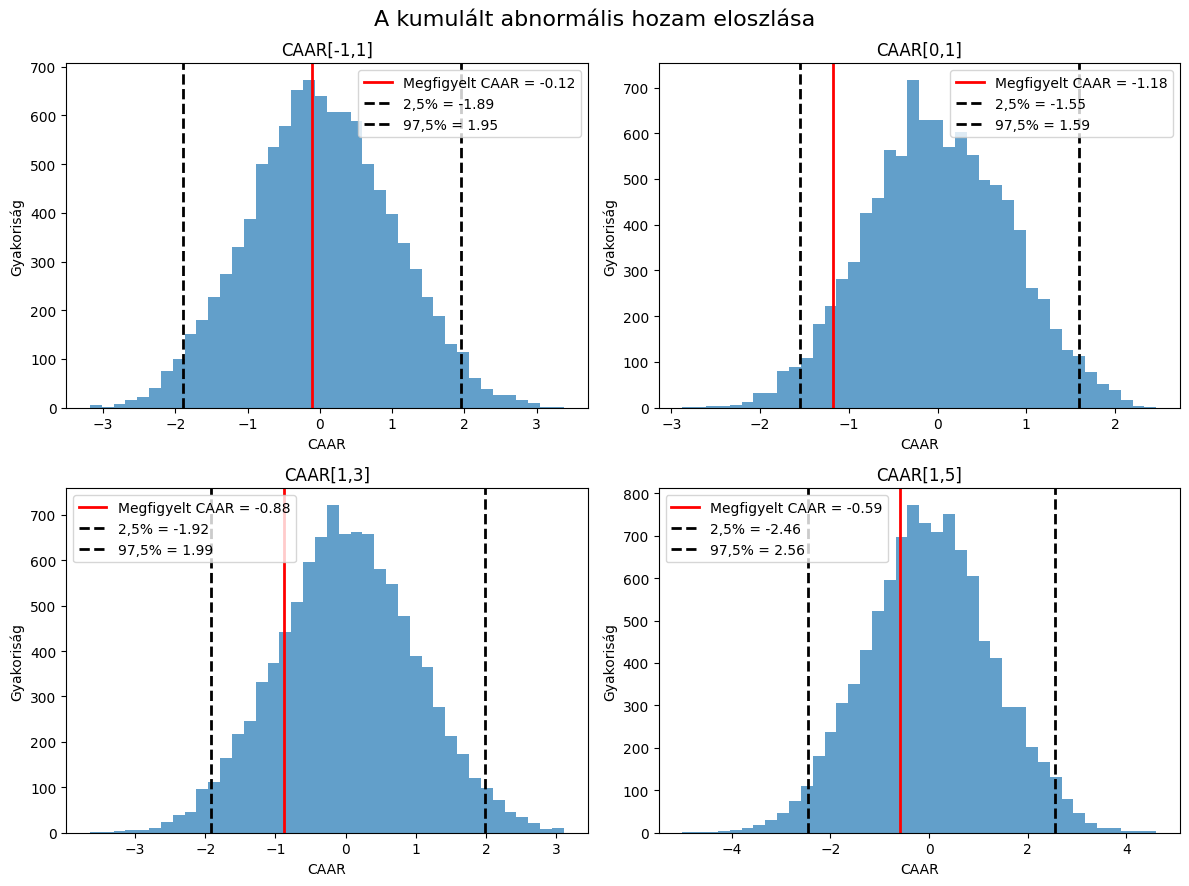

In [213]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(12,9))

ax[0,0].hist(CAAR_m1_p1_boot_null,bins=40,alpha=0.7)
ax[0,0].axvline(CAAR_null_output.loc["CAAR[-1,1]","Valós"],color="red",linewidth=2,label=f"Megfigyelt CAAR = {CAAR_null_output.loc["CAAR[-1,1]","Valós"]:.2f}")
ax[0,0].axvline(CAAR_null_output.loc["CAAR[-1,1]","2,5%"],color="black",linestyle="--",linewidth=2,label=f"2,5% = {CAAR_null_output.loc["CAAR[-1,1]","2,5%"]:.2f}")
ax[0,0].axvline(CAAR_null_output.loc["CAAR[-1,1]","97,5%"],color="black",linestyle="--",linewidth=2,label=f"97,5% = {CAAR_null_output.loc["CAAR[-1,1]","97,5%"]:.2f}")
ax[0,0].set_title("CAAR[-1,1]")
ax[0,0].set_xlabel("CAAR")
ax[0,0].set_ylabel("Gyakoriság")
ax[0,0].legend()

ax[0,1].hist(CAAR_0_p1_boot_null,bins=40,alpha=0.7)
ax[0,1].axvline(CAAR_null_output.loc["CAAR[0,1]","Valós"],color="red",linewidth=2,label=f"Megfigyelt CAAR = {CAAR_null_output.loc["CAAR[0,1]","Valós"]:.2f}")
ax[0,1].axvline(CAAR_null_output.loc["CAAR[0,1]","2,5%"],color="black",linestyle="--",linewidth=2,label=f"2,5% = {CAAR_null_output.loc["CAAR[0,1]","2,5%"]:.2f}")
ax[0,1].axvline(CAAR_null_output.loc["CAAR[0,1]","97,5%"],color="black",linestyle="--",linewidth=2,label=f"97,5% = {CAAR_null_output.loc["CAAR[0,1]","97,5%"]:.2f}")
ax[0,1].set_title("CAAR[0,1]")
ax[0,1].set_xlabel("CAAR")
ax[0,1].set_ylabel("Gyakoriság")
ax[0,1].legend()

ax[1,0].hist(CAAR_p1_p3_boot_null,bins=40,alpha=0.7)
ax[1,0].axvline(CAAR_null_output.loc["CAAR[1,3]","Valós"],color="red",linewidth=2,label=f"Megfigyelt CAAR = {CAAR_null_output.loc["CAAR[1,3]","Valós"]:.2f}")
ax[1,0].axvline(CAAR_null_output.loc["CAAR[1,3]","2,5%"],color="black",linestyle="--",linewidth=2,label=f"2,5% = {CAAR_null_output.loc["CAAR[1,3]","2,5%"]:.2f}")
ax[1,0].axvline(CAAR_null_output.loc["CAAR[1,3]","97,5%"],color="black",linestyle="--",linewidth=2,label=f"97,5% = {CAAR_null_output.loc["CAAR[1,3]","97,5%"]:.2f}")
ax[1,0].set_title("CAAR[1,3]")
ax[1,0].set_xlabel("CAAR")
ax[1,0].set_ylabel("Gyakoriság")
ax[1,0].legend()

ax[1,1].hist(CAAR_p1_p5_boot_null,bins=40,alpha=0.7)
ax[1,1].axvline(CAAR_null_output.loc["CAAR[1,5]","Valós"],color="red",linewidth=2,label=f"Megfigyelt CAAR = {CAAR_null_output.loc["CAAR[1,5]","Valós"]:.2f}")
ax[1,1].axvline(CAAR_null_output.loc["CAAR[1,5]","2,5%"],color="black",linestyle="--",linewidth=2,label=f"2,5% = {CAAR_null_output.loc["CAAR[1,5]","2,5%"]:.2f}")
ax[1,1].axvline(CAAR_null_output.loc["CAAR[1,5]","97,5%"],color="black",linestyle="--",linewidth=2,label=f"97,5% = {CAAR_null_output.loc["CAAR[1,5]","97,5%"]:.2f}")
ax[1,1].set_title("CAAR[1,5]")
ax[1,1].set_xlabel("CAAR")
ax[1,1].set_ylabel("Gyakoriság")
ax[1,1].legend()

fig.suptitle("A kumulált abnormális hozam eloszlása",size=16)
plt.tight_layout()

plt.savefig("Plots/CAAR.svg")

plt.show()

In [214]:
# Average abnormal returns by groups
AAR_stocks_trump=AR_event[stocks_trump].mean(axis=1)
AAR_stocks_harris=AR_event[stocks_harris].mean(axis=1)
AAR_stocks_tech=AR_event[stocks_tech].mean(axis=1)

AAR_output_dict={
    "Trump részvények":AAR_stocks_trump,
    "Harris részvények":AAR_stocks_harris,
    "Tech részvények":AAR_stocks_tech
}
AAR_output=pd.DataFrame(AAR_output_dict.values(),index=AAR_output_dict.keys(),columns=AAR_stocks_trump.index)
AAR_output.to_excel("Tables/AAR.xlsx",sheet_name="AAR")
AAR_output.head()

,-2,-1,0,1,2,3,4,5
Trump részvények,-1.537626,1.385257,0.167936,3.499659,-1.652263,2.828326,5.332748,-0.933474
Harris részvények,-1.505757,1.635704,0.471802,-6.199694,-0.212485,0.545392,-1.610826,-2.393022
Tech részvények,-0.953553,-0.450372,-0.901770,1.215235,-1.485547,-2.087902,0.703125,0.887650


In [175]:
# Bootstrap for AAR
AAR_trump_boot=list()
AAR_harris_boot=list()
AAR_tech_boot=list()

M=10_000

for i in range(M):
    print(f"===== {i}/{M} === {100*i/M:.2f}% =====",end="\r")
    df_boot=df.loc[estimation_window,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-7:])
    Y_boot=df_boot.loc[:,stocks_trump+stocks_harris+stocks_tech]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_trump+stocks_harris+stocks_tech].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_trump+stocks_harris+stocks_tech
    )
    AR_boot=AR_boot.reset_index(drop=True)
    AR_boot.index-=2
    
    AAR_trump_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,5),stocks_trump].mean(axis=1))
    AAR_harris_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,5),stocks_harris].mean(axis=1))
    AAR_tech_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,5),stocks_tech].mean(axis=1))


AAR_trump_p025=pd.Series(np.percentile(AAR_trump_boot,2.5,axis=0),index=range(-1,6))
AAR_trump_p975=pd.Series(np.percentile(AAR_trump_boot,97.5,axis=0),index=range(-1,6))

AAR_harris_p025=pd.Series(np.percentile(AAR_harris_boot,2.5,axis=0),index=range(-1,6))
AAR_harris_p975=pd.Series(np.percentile(AAR_harris_boot,97.5,axis=0),index=range(-1,6))

AAR_tech_p025=pd.Series(np.percentile(AAR_tech_boot,2.5,axis=0),index=range(-1,6))
AAR_tech_p975=pd.Series(np.percentile(AAR_tech_boot,97.5,axis=0),index=range(-1,6))

===== 9999/10000 === 99.99% =====

In [238]:
AAR_trump_output_dict={
    "AAR":AAR_output.loc["Trump részvények",-1:5],
    "2,5%":AAR_trump_p025,
    "97,5%":AAR_trump_p975
}
AAR_trump_output=pd.DataFrame(AAR_trump_output_dict.values(),index=AAR_trump_output_dict.keys(),columns=AAR_stocks_trump.index[1:])
AAR_trump_output.to_excel("Tables/AAR_trump.xlsx",sheet_name="AAR_trump")
AAR_trump_output.head()

AAR_harris_output_dict={
    "AAR":AAR_output.loc["Harris részvények",-1:5],
    "2,5%":AAR_harris_p025,
    "97,5%":AAR_harris_p975
}
AAR_harris_output=pd.DataFrame(AAR_harris_output_dict.values(),index=AAR_harris_output_dict.keys(),columns=AAR_stocks_harris.index[1:])
AAR_harris_output.to_excel("Tables/AAR_harris.xlsx",sheet_name="AAR_harris")
AAR_harris_output.head()

AAR_tech_output_dict={
    "AAR":AAR_output.loc["Tech részvények",-1:5],
    "2,5%":AAR_tech_p025,
    "97,5%":AAR_tech_p975
}
AAR_tech_output=pd.DataFrame(AAR_tech_output_dict.values(),index=AAR_tech_output_dict.keys(),columns=AAR_stocks_tech.index[1:])
AAR_tech_output.to_excel("Tables/AAR_tech.xlsx",sheet_name="AAR_tech")
AAR_tech_output.head()

,-1,0,1,2,3,4,5
AAR,-0.450372,-0.901770,1.215235,-1.485547,-2.087902,0.703125,0.887650
"2,5%",-0.647690,-1.230370,0.191547,-2.196583,-2.307461,0.504830,0.708496
"97,5%",0.133309,-0.787383,1.593589,-1.309925,-1.843690,0.874763,1.048389


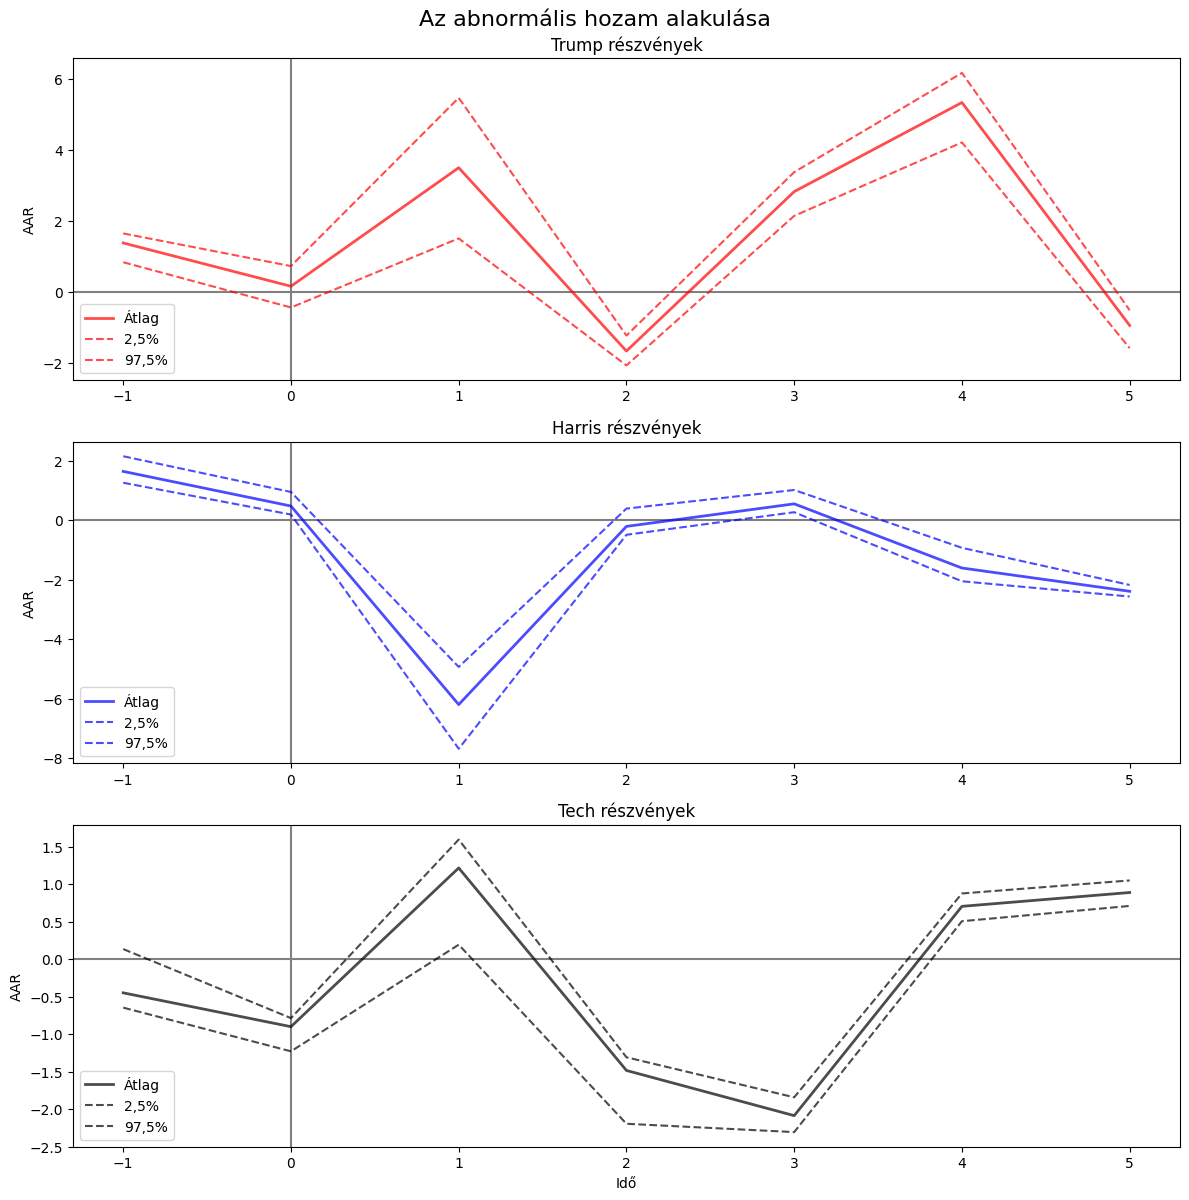

In [194]:
# Plot series
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(12,12))

ax[0].axhline(0,color="gray")
ax[0].axvline(0,color="gray")
ax[0].plot(AAR_output.loc["Trump részvények",-1:5],color="red",alpha=0.7,linewidth=2,label="Átlag")
ax[0].plot(AAR_trump_p025,color="red",alpha=0.7,linestyle="--",label="2,5%")
ax[0].plot(AAR_trump_p975,color="red",alpha=0.7,linestyle="--",label="97,5%")
ax[0].set_title("Trump részvények")
ax[0].set_ylabel("AAR")
ax[0].legend(loc="lower left")

ax[1].axhline(0,color="gray")
ax[1].axvline(0,color="gray")
ax[1].plot(AAR_output.loc["Harris részvények",-1:5],color="blue",alpha=0.7,linewidth=2,label="Átlag")
ax[1].plot(AAR_harris_p025,color="blue",alpha=0.7,linestyle="--",label="2,5%")
ax[1].plot(AAR_harris_p975,color="blue",alpha=0.7,linestyle="--",label="97,5%")
ax[1].set_title("Harris részvények")
ax[1].set_ylabel("AAR")
ax[1].legend(loc="lower left")

ax[2].axhline(0,color="gray")
ax[2].axvline(0,color="gray")
ax[2].plot(AAR_output.loc["Tech részvények",-1:5],color="black",alpha=0.7,linewidth=2,label="Átlag")
ax[2].plot(AAR_tech_p025,color="black",alpha=0.7,linestyle="--",label="2,5%")
ax[2].plot(AAR_tech_p975,color="black",alpha=0.7,linestyle="--",label="97,5%")
ax[2].set_title("Tech részvények")
ax[2].set_ylabel("AAR")
ax[2].legend(loc="lower left")

fig.suptitle("Az abnormális hozam alakulása",size=16)
plt.tight_layout()

plt.xlabel("Idő")

plt.savefig("Plots/AAR.svg")
plt.show()

In [220]:
# Bootstrap for CAAR grouped
CAAR_m1_p1_trump_boot=list()
CAAR_m1_p1_harris_boot=list()
CAAR_m1_p1_tech_boot=list()

CAAR_0_p1_trump_boot=list()
CAAR_0_p1_harris_boot=list()
CAAR_0_p1_tech_boot=list()

CAAR_p1_p3_trump_boot=list()
CAAR_p1_p3_harris_boot=list()
CAAR_p1_p3_tech_boot=list()

CAAR_p1_p5_trump_boot=list()
CAAR_p1_p5_harris_boot=list()
CAAR_p1_p5_tech_boot=list()

M=10_000

for i in range(M):
    print(f"===== {i}/{M} === {100*i/M:.2f}% =====",end="\r")
    AR_boot=AR_estim.sample(8,replace=True).reset_index(drop=True)
    AR_boot.index-=2

    CAAR_m1_p1_trump_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,1),stocks_trump].mean(axis=1).sum())
    CAAR_m1_p1_harris_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,1),stocks_harris].mean(axis=1).sum())
    CAAR_m1_p1_tech_boot.append(AR_boot.loc[AR_boot.index.to_series().between(-1,1),stocks_tech].mean(axis=1).sum())
    
    CAAR_0_p1_trump_boot.append(AR_boot.loc[AR_boot.index.to_series().between(0,1),stocks_trump].mean(axis=1).sum())
    CAAR_0_p1_harris_boot.append(AR_boot.loc[AR_boot.index.to_series().between(0,1),stocks_harris].mean(axis=1).sum())
    CAAR_0_p1_tech_boot.append(AR_boot.loc[AR_boot.index.to_series().between(0,1),stocks_tech].mean(axis=1).sum())
    
    CAAR_p1_p3_trump_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,3),stocks_trump].mean(axis=1).sum())
    CAAR_p1_p3_harris_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,3),stocks_harris].mean(axis=1).sum())
    CAAR_p1_p3_tech_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,3),stocks_tech].mean(axis=1).sum())
    
    CAAR_p1_p5_trump_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,5),stocks_trump].mean(axis=1).sum())
    CAAR_p1_p5_harris_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,5),stocks_harris].mean(axis=1).sum())
    CAAR_p1_p5_tech_boot.append(AR_boot.loc[AR_boot.index.to_series().between(1,5),stocks_tech].mean(axis=1).sum())


CAAR_grouped_output_dict={
    "Trump részvények":[
        AR_event.loc[AR_event.index.to_series().between(-1,1),stocks_trump].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(0,1),stocks_trump].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,3),stocks_trump].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,5),stocks_trump].mean(axis=1).sum()
    ],
    "Harris részvények":[
        AR_event.loc[AR_event.index.to_series().between(-1,1),stocks_harris].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(0,1),stocks_harris].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,3),stocks_harris].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,5),stocks_harris].mean(axis=1).sum()
    ],
    "Tech részvények":[
        AR_event.loc[AR_event.index.to_series().between(-1,1),stocks_tech].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(0,1),stocks_tech].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,3),stocks_tech].mean(axis=1).sum(),
        AR_event.loc[AR_event.index.to_series().between(1,5),stocks_tech].mean(axis=1).sum()
    ],
}

CAAR_grouped_output=pd.DataFrame(CAAR_grouped_output_dict.values(),index=CAAR_grouped_output_dict.keys(),columns=["CAAR[-1,1]","CAAR[0,1]","CAAR[1,3]","CAAR[1,5]"])
CAAR_grouped_output.to_excel("Tables/CAAR grouped.xlsx",sheet_name="CAAR grouped")
CAAR_grouped_output.head()

===== 9999/10000 === 99.99% =====

,"CAAR[-1,1]","CAAR[0,1]","CAAR[1,3]","CAAR[1,5]"
Trump részvények,5.052852,3.667595,4.675722,9.074996
Harris részvények,-4.092189,-5.727892,-5.866787,-9.870636
Tech részvények,-0.136906,0.313466,-2.358214,-0.767439


In [234]:
# CAAR grouped confidence interval
CAAR_m1_p1_grouped_dict={
    "Valós":AAR_output.loc[:,AAR_output.columns.to_series().between(-1,1)].sum(axis=1),
    "Átlag":[np.mean(CAAR_m1_p1_trump_boot),np.mean(CAAR_m1_p1_harris_boot),np.mean(CAAR_m1_p1_tech_boot)],
    "Medián":[np.percentile(CAAR_m1_p1_trump_boot,50),np.percentile(CAAR_m1_p1_harris_boot,50),np.percentile(CAAR_m1_p1_tech_boot,50)],
    "2,5%":[np.percentile(CAAR_m1_p1_trump_boot,2.5),np.percentile(CAAR_m1_p1_harris_boot,2.5),np.percentile(CAAR_m1_p1_tech_boot,2.5)],
    "97,5%":[np.percentile(CAAR_m1_p1_trump_boot,97.5),np.percentile(CAAR_m1_p1_harris_boot,97.5),np.percentile(CAAR_m1_p1_tech_boot,97.5)]
}
CAAR_0_p1_grouped_dict={
    "Valós":AAR_output.loc[:,AAR_output.columns.to_series().between(0,1)].sum(axis=1),
    "Átlag":[np.mean(CAAR_0_p1_trump_boot),np.mean(CAAR_0_p1_harris_boot),np.mean(CAAR_0_p1_tech_boot)],
    "Medián":[np.percentile(CAAR_0_p1_trump_boot,50),np.percentile(CAAR_0_p1_harris_boot,50),np.percentile(CAAR_0_p1_tech_boot,50)],
    "2,5%":[np.percentile(CAAR_0_p1_trump_boot,2.5),np.percentile(CAAR_0_p1_harris_boot,2.5),np.percentile(CAAR_0_p1_tech_boot,2.5)],
    "97,5%":[np.percentile(CAAR_0_p1_trump_boot,97.5),np.percentile(CAAR_0_p1_harris_boot,97.5),np.percentile(CAAR_0_p1_tech_boot,97.5)]
}
CAAR_p1_p3_grouped_dict={
    "Valós":AAR_output.loc[:,AAR_output.columns.to_series().between(1,3)].sum(axis=1),
    "Átlag":[np.mean(CAAR_p1_p3_trump_boot),np.mean(CAAR_p1_p3_harris_boot),np.mean(CAAR_p1_p3_tech_boot)],
    "Medián":[np.percentile(CAAR_p1_p3_trump_boot,50),np.percentile(CAAR_p1_p3_harris_boot,50),np.percentile(CAAR_p1_p3_tech_boot,50)],
    "2,5%":[np.percentile(CAAR_p1_p3_trump_boot,2.5),np.percentile(CAAR_p1_p3_harris_boot,2.5),np.percentile(CAAR_p1_p3_tech_boot,2.5)],
    "97,5%":[np.percentile(CAAR_p1_p3_trump_boot,97.5),np.percentile(CAAR_p1_p3_harris_boot,97.5),np.percentile(CAAR_p1_p3_tech_boot,97.5)]
}
CAAR_p1_p5_grouped_dict={
    "Valós":AAR_output.loc[:,AAR_output.columns.to_series().between(1,5)].sum(axis=1),
    "Átlag":[np.mean(CAAR_p1_p5_trump_boot),np.mean(CAAR_p1_p5_harris_boot),np.mean(CAAR_p1_p5_tech_boot)],
    "Medián":[np.percentile(CAAR_p1_p5_trump_boot,50),np.percentile(CAAR_p1_p5_harris_boot,50),np.percentile(CAAR_p1_p5_tech_boot,50)],
    "2,5%":[np.percentile(CAAR_p1_p5_trump_boot,2.5),np.percentile(CAAR_p1_p5_harris_boot,2.5),np.percentile(CAAR_p1_p5_tech_boot,2.5)],
    "97,5%":[np.percentile(CAAR_p1_p5_trump_boot,97.5),np.percentile(CAAR_p1_p5_harris_boot,97.5),np.percentile(CAAR_p1_p5_tech_boot,97.5)]
}

CAAR_m1_p1_grouped=pd.DataFrame(CAAR_m1_p1_grouped_dict,index=["Trump részvények","Harris részvények","Tech részvények"])
CAAR_0_p1_grouped=pd.DataFrame(CAAR_0_p1_grouped_dict,index=["Trump részvények","Harris részvények","Tech részvények"])
CAAR_p1_p3_grouped=pd.DataFrame(CAAR_p1_p3_grouped_dict,index=["Trump részvények","Harris részvények","Tech részvények"])
CAAR_p1_p5_grouped=pd.DataFrame(CAAR_p1_p5_grouped_dict,index=["Trump részvények","Harris részvények","Tech részvények"])

CAAR_m1_p1_grouped.to_excel("Tables/CAAR_-1_1_.xlsx",sheet_name="CAAR_-1_1_.xlsx")
CAAR_0_p1_grouped.to_excel("Tables/CAAR_0_1_.xlsx",sheet_name="CAAR_0_1_.xlsx")
CAAR_p1_p3_grouped.to_excel("Tables/CAAR_1_3_.xlsx",sheet_name="CAAR_1_3_.xlsx")
CAAR_p1_p5_grouped.to_excel("Tables/CAAR_1_5_.xlsx",sheet_name="CAAR_1_5_.xlsx")

In [16]:
# Bootstrap for Trump stocks
AAR_boot_trump=list()
AAR_boot_t_trump=list()
CAAR_boot_trump=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-7:])
    Y_boot=df_boot.loc[:,stocks_trump]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_trump].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_trump
    )
    AAR_boot_trump.append(list(AR_boot.mean(axis=1)))
    AAR_boot_t_trump.append(list(AR_boot.mean(axis=1)/(AR_boot.std(axis=1,ddof=1)/len(AR_boot.columns))))
    CAAR_boot_trump.append(AR_boot.mean(axis=1).cumsum())

p10_trump=np.percentile(AAR_boot_trump,2.5,axis=0)
med_trump=np.percentile(AAR_boot_trump,50,axis=0)
p90_trump=np.percentile(AAR_boot_trump,97.5,axis=0)

p10_trump_c=np.percentile(CAAR_boot_trump,2.5,axis=0)
med_trump_c=np.percentile(CAAR_boot_trump,50,axis=0)
p90_trump_c=np.percentile(CAAR_boot_trump,97.5,axis=0)

In [18]:
# Bootstrap for Harris stocks
AAR_boot_harris=list()
CAAR_boot_harris=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-7:])
    Y_boot=df_boot.loc[:,stocks_harris]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_harris].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_harris
    )
    AAR_boot_harris.append(list(AR_boot.mean(axis=1)))
    CAAR_boot_harris.append(AR_boot.mean(axis=1).cumsum())

p10_harris=np.percentile(AAR_boot_harris,2.5,axis=0)
med_harris=np.percentile(AAR_boot_harris,50,axis=0)
p90_harris=np.percentile(AAR_boot_harris,97.5,axis=0)

p10_harris_c=np.percentile(CAAR_boot_harris,2.5,axis=0)
med_harris_c=np.percentile(CAAR_boot_harris,50,axis=0)
p90_harris_c=np.percentile(CAAR_boot_harris,97.5,axis=0)

In [20]:
# Bootstrap for Tech stocks
AAR_boot_tech=list()
CAAR_boot_tech=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-7:])
    Y_boot=df_boot.loc[:,stocks_tech]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_tech].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_tech
    )
    AAR_boot_tech.append(list(AR_boot.mean(axis=1)))
    CAAR_boot_tech.append(AR_boot.mean(axis=1).cumsum())

p10_tech=np.percentile(AAR_boot_tech,2.5,axis=0)
med_tech=np.percentile(AAR_boot_tech,50,axis=0)
p90_tech=np.percentile(AAR_boot_tech,97.5,axis=0)

p10_tech_c=np.percentile(CAAR_boot_tech,2.5,axis=0)
med_tech_c=np.percentile(CAAR_boot_tech,50,axis=0)
p90_tech_c=np.percentile(CAAR_boot_tech,97.5,axis=0)

In [175]:
# Histogram function
def hist_abnormal(data,obs,label=None,alpha=None,xlab=None):
    #data=[caar[caar.index[-1]] for caar in data]
    obs=sum(obs)
    
    if alpha is None:
        alpha=10
    q1=np.percentile(data,alpha/2,axis=0)
    q2=np.percentile(data,100-alpha/2,axis=0)

    plt.figure()
    plt.hist(
        data,
        bins=40,
        alpha=0.7
    )

    plt.axvline(obs,color="red",linewidth=2,label=f"Megfigyelt CAAR = {obs:.4f}")
    plt.axvline(q1,color="black",linestyle="--",linewidth=2,label=f"{alpha/2}% = {q1:.4f}")
    plt.axvline(q2,color="black",linestyle="--",linewidth=2,label=f"{100-alpha/2}% = {q2:.4f}")

    plt.title(f"{xlab} eloszlása ({label})")
    plt.xlabel(xlab)
    plt.ylabel("Gyakoriság")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{xlab}_{label}.png")
    plt.show()

In [145]:
def calculate_iteration(data,indexes=None,event_start=-2,event_end=5):
    if indexes is not None:
        new_data=data.loc[indexes].copy()
    else:
        new_data=data.copy()

    new_data["index"]=1
    new_data["index"]=new_data["index"].cumsum()
    new_data["index"]-=new_data.shape[0]-5

    window=new_data.loc[new_data["index"].between(event_start,event_end)].drop(columns="index")
    car=window.sum(axis=0)

    ar_all=window[stocks_trump+stocks_harris+stocks_tech]
    ar_trump=window[stocks_trump]
    ar_harris=window[stocks_harris]
    ar_tech=window[stocks_tech]

    car_all=car[stocks_trump+stocks_harris+stocks_tech].mean()
    car_trump=car[stocks_trump].mean()
    car_harris=car[stocks_harris].mean()
    car_tech=car[stocks_tech].mean()

    return ar_all,car_all,ar_trump,car_trump,ar_harris,car_harris,ar_tech,car_tech

In [178]:
Y_pred_estim=ff5_mom_model.predict(X_estim)
Y_pred_estim.columns=Y_estim.columns
AR_estim=Y_estim-Y_pred_estim

ar_all=list()
ar_trump=list()
ar_harris=list()
ar_tech=list()

caar_all=list()
caar_trump=list()
caar_harris=list()
caar_tech=list()

for _ in range(10_000):
    caars=calculate_iteration(AR_estim,indexes=np.random.permutation(AR_estim.index),event_start=1)
    ar_all.append(caars[0])
    ar_trump.append(caars[2])
    ar_harris.append(caars[4])
    ar_tech.append(caars[6])
    
    caar_all.append(caars[1])
    caar_trump.append(caars[3])
    caar_harris.append(caars[5])
    caar_tech.append(caars[7])

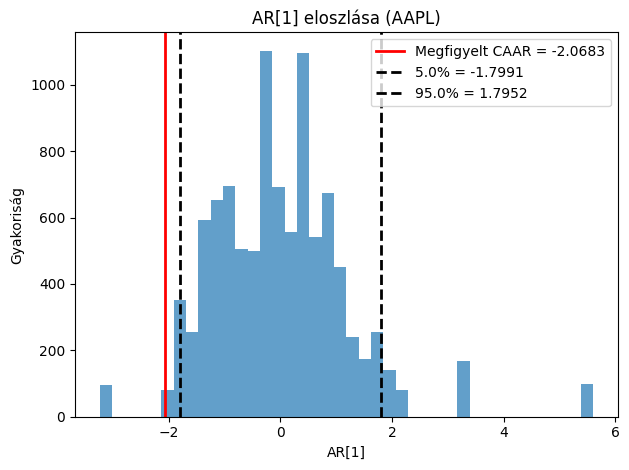

In [218]:
def plot_ticker_ar(ar_all,ticker,day_no=1,xlab=None):
    ticker_ar=[ar.loc[ar.index[day_no+2],ticker] for ar in ar_all]
    hist_abnormal(ticker_ar,[AR_event.loc[AR_event.index[day_no+2],ticker]],label=ticker.upper(),xlab=xlab)

plot_ticker_ar(ar_all,"aapl",day_no=1,xlab="AR[1]")

In [215]:
def get_ticker_ar_pval(ar_all,ar_observed,tickers,days):
    ars_pval=pd.DataFrame(index=days,columns=tickers)

    ar_obs=ar_observed.reset_index()
    ar_obs.index-=2
    ar_obs=ar_obs.loc[days,tickers]

    for t in tickers:
        for d in days:
            ars_pval.at[d,t]=np.mean(np.abs(np.array([ar.loc[ar.index[d-1],t] for ar in ar_all]))>=np.abs(ar_obs.loc[d,t]))

    print(ars_pval.head())

get_ticker_ar_pval(ar_all,AR_event,stocks_tech,list(range(1,6)))

     aapl    goog    nvda
1  0.0411  0.0487   0.058
2  0.9593  0.5681  0.0094
3  0.6247  0.0391  0.0726
4  0.2212  0.6912  0.1002
5  0.7294  0.1887  0.5794


In [206]:
AR_event["coin"].iloc[3]

np.float64(15.526555731344132)

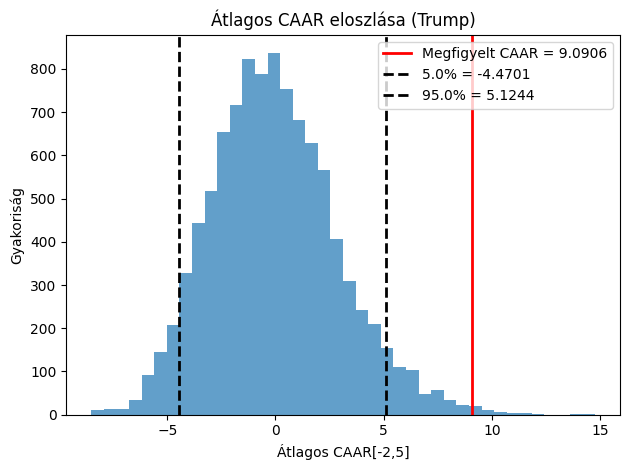

In [79]:
hist_abnormal(caar_trump,AAR_stocks_trump,label="Trump")

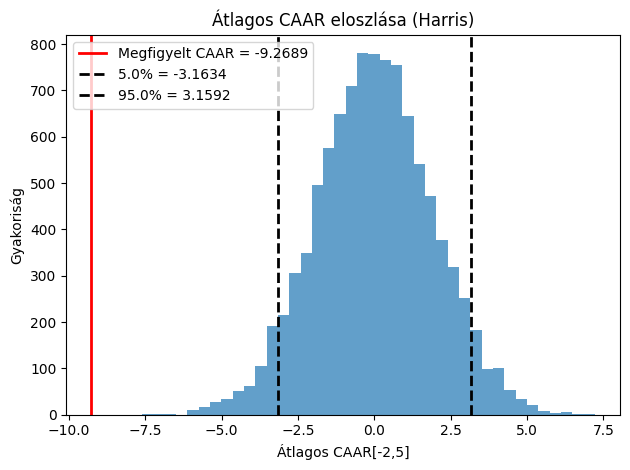

In [80]:
hist_abnormal(caar_harris,AAR_stocks_harris,label="Harris")

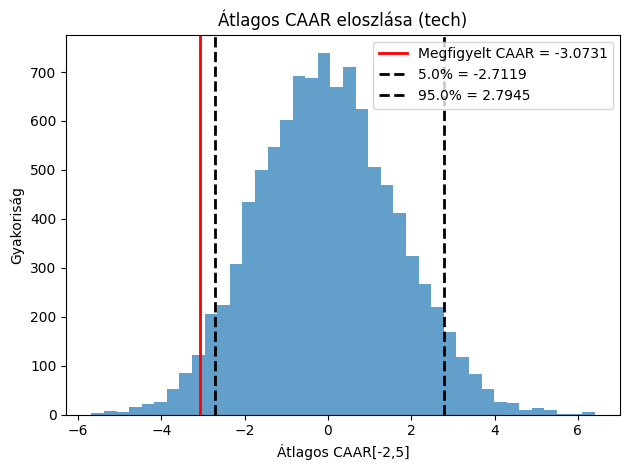

In [81]:
hist_abnormal(caar_tech,AAR_stocks_tech,label="tech")